In [ ]:
# !pip install --upgrade git+http://github.com/davin11/easy-cv-dataset keras-cv

In [ ]:
# !wget -q -c https://www.grip.unina.it/download/guide_TF/TrafficSigns.zip

In [ ]:
# !unzip -q -n TrafficSigns.zip

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import skimage.io as io
import scipy.ndimage as ndi
import easy_cv_dataset as ds
import tensorflow.keras as keras
from sklearn.model_selection import train_test_split
from keras_cv.layers import Resizing
from skimage.transform import resize
from keras_cv.layers import RandomBrightness, RandomZoom, Augmenter # Per Data Augmentation

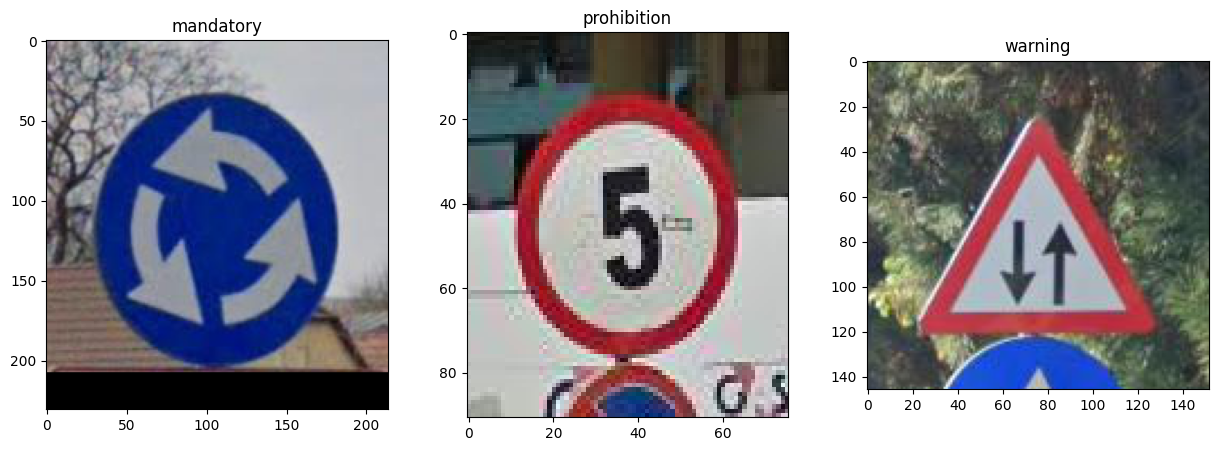

,image,class
0,TrafficSigns/train/mandatory/00033_00001_00029...,mandatory
1,TrafficSigns/train/mandatory/00033_00002_00029...,mandatory
2,TrafficSigns/train/mandatory/00033_00003_00029...,mandatory
3,TrafficSigns/train/mandatory/00033_00004_00029...,mandatory
4,TrafficSigns/train/mandatory/00033_00005_00029...,mandatory
...,...,...
3835,TrafficSigns/train/warning/img5248_00.png,warning
3836,TrafficSigns/train/warning/img5249_00.png,warning
3837,TrafficSigns/train/warning/img5250_00.png,warning
3838,TrafficSigns/train/warning/img5251_00.png,warning


For class 'mandatory', there are 1024 images.
For class 'prohibition', there are 1024 images.
For class 'warning', there are 1024 images.
shuffling with buffer_size 80
For class 'mandatory', there are 256 images.
For class 'prohibition', there are 256 images.
For class 'warning', there are 256 images.


In [ ]:
# Preparazione dei dati
img0 = io.imread('TrafficSigns/train/mandatory/img0065_00.png')
img1 = io.imread('TrafficSigns/train/prohibition/img2929_00.png')
img2 = io.imread('TrafficSigns/train/warning/img2470_00.png')
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(img0); plt.title('mandatory')
plt.subplot(1,3,2); plt.imshow(img1); plt.title('prohibition')
plt.subplot(1,3,3); plt.imshow(img2); plt.title('warning')
plt.show()

# Augmentation
augmenter = Augmenter(layers=[
                            RandomBrightness(factor=(-0.1, 0.1), value_range=(0, 255)),
                            RandomZoom((-0.2,0.2)),
                            ])

train_table=ds.image_dataframe_from_directory('TrafficSigns/train')
display(train_table)
train_table,valid_table=train_test_split(train_table,test_size=0.2,
                                          random_state=34,
                                          stratify=train_table['class'])

batch_size=8
img_height,img_width=150,150

train_dataset=ds.image_classification_dataset_from_dataframe(train_table, 
                                                            batch_size=batch_size,    shuffle=True,
                                                            pre_batching_processing=Resizing(img_height,img_width),
                                                            post_batching_processing=augmenter,
                                                            do_normalization=True,
                                                            class_mode='categorical') #categorical -> OneHot
                                                            # augmenter per la augmentation dei dati, None per niente

valid_dataset = ds.image_classification_dataset_from_dataframe(valid_table, batch_size=batch_size, shuffle=False,
                                                                pre_batching_processing=Resizing(img_height, img_width),
                                                                do_normalization=True,
                                                                class_mode='categorical')

In [36]:
# Fine tuning
base_model = keras.applications.ResNet50(weights='imagenet', include_top=False,
                                          input_shape=(img_width, img_height, 3)) # Resnet-50 pre addestrata

model = keras.models.Sequential()
model.add(base_model)
model.add(keras.layers.GlobalAveragePooling2D())
model.add(keras.layers.Dense(3, activation='softmax'))
model.summary()

train_after_layer = 25
for layer in base_model.layers[:train_after_layer]:
  layer.trainable = False


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 23,540,739 (89.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [37]:
# Training
model.compile(loss='categorical_crossentropy',
              optimizer=keras.optimizers.SGD(learning_rate=1e-4, momentum=0.9),
              metrics=['accuracy', ])

# possiamo usare un learning rate molto basso perchè non partiamo da pesi random, quindi non c'è il rischio del vanishing gradient

model.fit(train_dataset, epochs=1, validation_data=valid_dataset, verbose=True)

384/384 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.7875 - loss: 0.5193 - val_accuracy: 0.9362 - val_loss: 0.1755


In [38]:
# Analisi delle prestazioni

test_table = ds.image_dataframe_from_directory('TrafficSigns/test')
test_dataset = ds.image_classification_dataset_from_dataframe(test_table, batch_size=batch_size, shuffle=False,
                                                                pre_batching_processing=Resizing(img_height, img_width),
                                                                do_normalization=True,
                                                                class_mode='categorical')
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=True)
print('Test loss:', test_loss)
print('Test accuracy:',test_accuracy)

For class 'mandatory', there are 256 images.
For class 'prohibition', there are 256 images.
For class 'warning', there are 256 images.
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9643 - loss: 0.1261
Test loss: 0.1733769178390503
Test accuracy: 0.9440104365348816


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


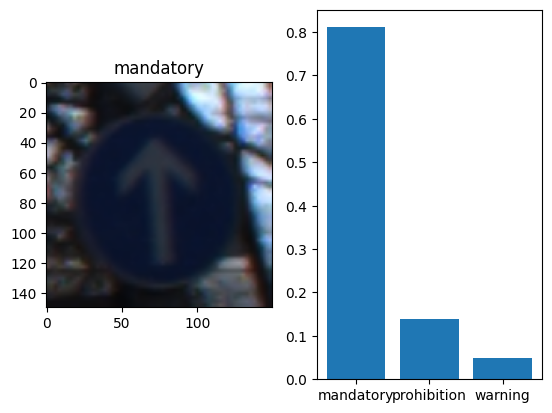

In [41]:
# Prova con qualche immagine

ID = 10
filename = test_table.loc[ID, 'image']
cls = test_table.loc[ID, 'class']

img = np.float32(io.imread(filename))/255
img = resize(img, (img_height, img_width))
x = np.reshape(img, (1, img_height, img_width, 3)) # 1 -> solo un'immagine da calcolare

pred = model.predict(x)[0,:]

plt.figure()
plt.subplot(1,2,1)
plt.imshow(img)
plt.title(cls)
plt.subplot(1,2,2)
plt.bar(np.arange(3), pred)
plt.xticks(np.arange(3), ['mandatory', 'prohibition', 'warning'])
plt.show()